# 04 - VAE Synthesis

Train VAE on ESC-50 mel spectrograms and inspect reconstructions.

In [1]:
from __future__ import annotations

import torch
from IPython.display import Audio, display

from src import config
from src.data.dataloaders import get_dataloaders
from src.models import checkpoints
from src.models.trainer import ModelTrainer
from src.models.vae import VAESynthesizer
from src.visualization.visualize import mel_to_audio, plot_spectrogram_pair, plot_training_history

device = config.get_device()
print(config.describe_device(device))

cuda:0 (NVIDIA GeForce RTX 4060 Ti, torch 2.12.0+cu126)


Training on: cuda:0 (NVIDIA GeForce RTX 4060 Ti, torch 2.12.0+cu126)
Epoch 1/50 beta_kl=0.005 train_loss=4.1094 train_recon=3.9462 train_kl=32.6210 val_loss=4.0929 val_recon=4.0907 val_kl=0.4301
Saved best vae (epoch 1) val_loss=4.0929 val_acc=0.0000 -> C:\Users\ekurm\projects\nature-sound-generator\models\checkpoints\vae\best.pt
Epoch 2/50 beta_kl=0.010 train_loss=3.9950 train_recon=3.9930 train_kl=0.1988 val_loss=3.8982 val_recon=3.8973 val_kl=0.0893
Saved best vae (epoch 2) val_loss=3.8982 val_acc=0.0000 -> C:\Users\ekurm\projects\nature-sound-generator\models\checkpoints\vae\best.pt
Epoch 3/50 beta_kl=0.015 train_loss=3.6742 train_recon=3.6582 train_kl=1.0659 val_loss=3.5663 val_recon=3.5636 val_kl=0.1751
Saved best vae (epoch 3) val_loss=3.5663 val_acc=0.0000 -> C:\Users\ekurm\projects\nature-sound-generator\models\checkpoints\vae\best.pt
Epoch 4/50 beta_kl=0.020 train_loss=3.7509 train_recon=3.7443 train_kl=0.3326 val_loss=3.9457 val_recon=3.9454 val_kl=0.0162
Epoch 5/50 beta_kl=

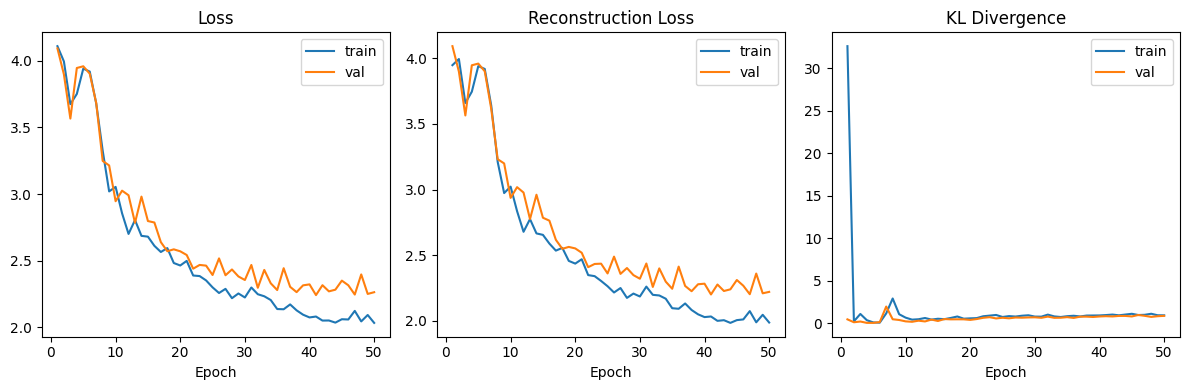

VAE target class: 14
VAE batch size: 8, crop seconds: 4.0, beta_kl: 0.05, delta_weight: 0.5


In [2]:
train_loader, val_loader, test_loader = get_dataloaders(
    "vae",
    batch_size=config.BATCH_SIZE_VAE,
    vae_target_class=config.VAE_TARGET_CLASS,
)
model = VAESynthesizer(latent_dim=128)
trainer = ModelTrainer(model, device=device, model_name="vae")
history = trainer.train_vae(
    train_loader,
    val_loader,
    epochs=config.EPOCHS_VAE,
    beta_kl=config.VAE_BETA_KL,
    kl_warmup_epochs=config.VAE_KL_WARMUP_EPOCHS,
    delta_weight=config.VAE_DELTA_LOSS_WEIGHT,
)
plot_training_history(history)
print(f"VAE target class: {config.VAE_TARGET_CLASS}")
print(
    f"VAE batch size: {config.BATCH_SIZE_VAE}, crop seconds: {config.VAE_CROP_SECONDS}, "
    f"beta_kl: {config.VAE_BETA_KL}, delta_weight: {config.VAE_DELTA_LOSS_WEIGHT}"
)

In [5]:
payload = checkpoints.load_best("vae", model)
if payload is None:
    print("Best VAE checkpoint not found yet; using current in-memory weights.")
else:
    print(
        f"Loaded best checkpoint: epoch={payload['epoch']} "
        f"val_loss={payload['metrics'].get('val_loss', float('nan')):.4f}"
    )

Loaded best vae (epoch=50, val_loss=6.7975, val_acc=0.0000)
Loaded best checkpoint: epoch=50 val_loss=6.7975


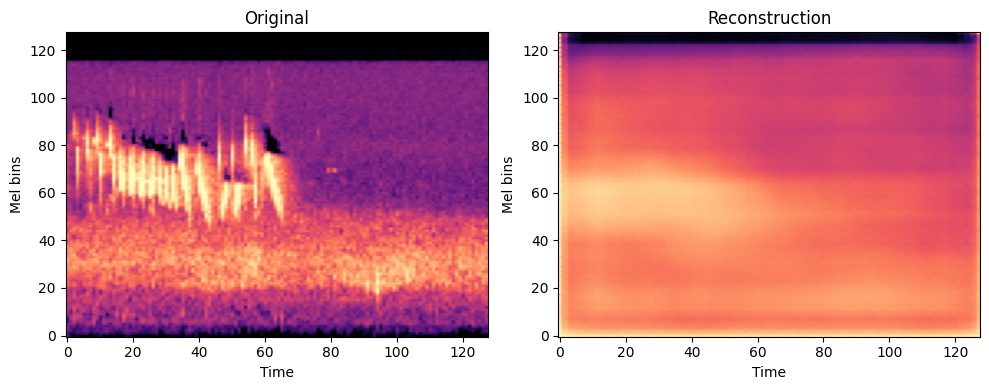

mu norm: 14.002, logvar mean: -1.540


In [3]:
model.eval()
mels, _ = next(iter(test_loader))
mels = mels.to(device)
with torch.no_grad():
    recon, mu, logvar = model(mels)

idx = 0
plot_spectrogram_pair(mels[idx].cpu(), recon[idx].cpu())
print(f"mu norm: {mu[idx].norm().item():.3f}, logvar mean: {logvar[idx].mean().item():.3f}")

In [4]:
# Optional: quick listening comparison from log-mel.
orig_wave = mel_to_audio(mels[idx].cpu(), input_scale="log")
recon_wave = mel_to_audio(recon[idx].cpu(), input_scale="log")

print("Original")
display(Audio(orig_wave.squeeze(0).numpy(), rate=config.SAMPLE_RATE))
print("Reconstruction")
display(Audio(recon_wave.squeeze(0).numpy(), rate=config.SAMPLE_RATE))

Original


Reconstruction


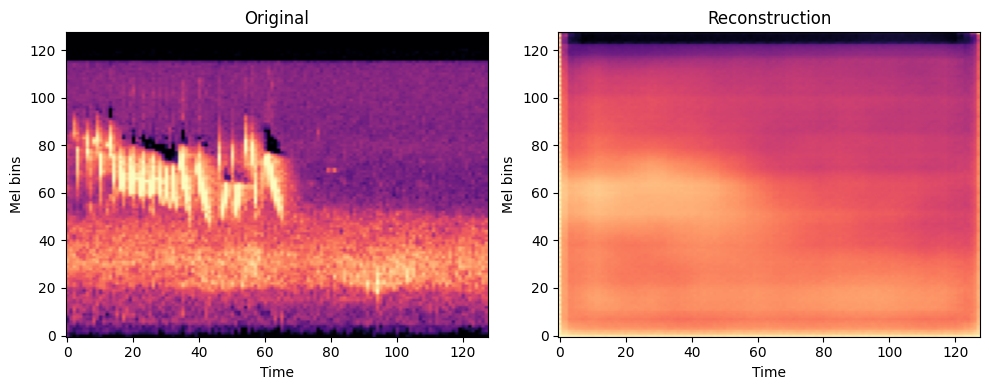

Generated (posterior-neighborhood)


In [5]:
# Bird-like generation from posterior neighborhood (usually better than pure N(0,1) prior).
model.eval()
with torch.no_grad():
    z_base = mu[idx : idx + 1]
    z_gen = z_base + 0.15 * torch.randn_like(z_base)
    gen = model.decode(z_gen).cpu()

plot_spectrogram_pair(mels[idx].cpu(), gen[0])
gen_wave = mel_to_audio(gen[0], input_scale="log")
print("Generated (posterior-neighborhood)")
display(Audio(gen_wave.squeeze(0).numpy(), rate=config.SAMPLE_RATE))